# CS4305 Artificial Intelligence — Lab 7
## Knowledge-Directed (Heuristic) Search

**What you will learn today**
1. What a **heuristic** is — an educated guess of the distance to the goal
2. **Greedy Best-First Search**: f(n) = h(n)
3. **A\* Search**: f(n) = g(n) + h(n)
4. Why a good heuristic saves a lot of work (8-puzzle)
5. **Hill Climbing** and its main problem
6. A first look at game search: **Minimax**

**How to use this notebook**
- 📊 **Visual explanation** cells already show a picture. Look at the picture first, then read the code.
- 💻 **Code** cells: click inside and press **Shift + Enter** to run them, from top to bottom.
- 📝 **Lab tasks** are at the end.

In [ ]:
#@title ⚙️ Diagram tools (only needed if you want to redraw the pictures)
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch, Rectangle

PURPLE, ORANGE, TEAL, ROSE, DARK = "#5B2A86", "#FF9F1C", "#1FA898", "#D1495B", "#1A1333"
LIGHT, GREY, WHITE = "#F3EEFA", "#A9A3B8", "#FFFFFF"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 12})

def tree_layout(children, root, gap=1.0):
    """Tidy layout for a tree given as {parent: [children]}."""
    pos, nxt = {}, [0.0]
    def walk(n, d):
        kids = children.get(n, [])
        if not kids:
            pos[n] = (nxt[0], -d); nxt[0] += gap
        else:
            for k in kids: walk(k, d + 1)
            xs = [pos[k][0] for k in kids]
            pos[n] = ((min(xs) + max(xs)) / 2, -d)
    walk(root, 0)
    return pos

def draw_graph(ax, pos, edges, directed=False, weights=None, colors=None, path=None, r=0.28,
               fs=13, label_below=False, badges=None, badge_color=ORANGE, edge_fs=11, names=None):
    """Draw nodes (circles) and edges. path = list of nodes to highlight in orange."""
    colors = colors or {}
    on_path = set()
    if path:
        for a, b in zip(path, path[1:]): on_path |= {(a, b), (b, a)}
    for i, (a, b) in enumerate(edges):
        (x1, y1), (x2, y2) = pos[a], pos[b]
        L = math.hypot(x2 - x1, y2 - y1); ux, uy = (x2 - x1) / L, (y2 - y1) / L
        s, e = (x1 + ux * r, y1 + uy * r), (x2 - ux * r, y2 - uy * r)
        hi = (a, b) in on_path
        ax.annotate("", xy=e, xytext=s, arrowprops=dict(arrowstyle="-|>" if directed else "-",
                    color=ORANGE if hi else GREY, lw=4 if hi else 1.8, shrinkA=0, shrinkB=0,
                    mutation_scale=18), zorder=1)
        if weights:
            w = weights[i]
            ax.text((x1 + x2) / 2, (y1 + y2) / 2, str(w), ha="center", va="center", fontsize=edge_fs,
                    color=DARK, fontweight="bold", zorder=4,
                    bbox=dict(boxstyle="round,pad=0.2", fc=WHITE, ec="none"))
    for n, (x, y) in pos.items():
        c = colors.get(n, PURPLE)
        ax.add_patch(Circle((x, y), r, fc=c, ec=WHITE, lw=2, zorder=3))
        text = (names or {}).get(n, n)
        if label_below:
            ax.text(x, y - r - 0.06, text, ha="center", va="top", fontsize=fs, color=DARK, fontweight="bold", zorder=5)
        else:
            ax.text(x, y, text, ha="center", va="center", fontsize=fs, color=WHITE if c not in (ORANGE, LIGHT, WHITE) else DARK,
                    fontweight="bold", zorder=5)
    if badges:
        for n, t in badges.items():
            x, y = pos[n]
            ax.add_patch(Circle((x + r * 0.95, y + r * 0.95), r * 0.55, fc=badge_color, ec=WHITE, lw=1.5, zorder=6))
            ax.text(x + r * 0.95, y + r * 0.95, str(t), ha="center", va="center", fontsize=fs - 3,
                    color=DARK, fontweight="bold", zorder=7)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    m = r * 2.2
    ax.set_xlim(min(xs) - m, max(xs) + m); ax.set_ylim(min(ys) - m - (0.35 if label_below else 0), max(ys) + m)
    ax.set_aspect("equal"); ax.axis("off")

def box(ax, x, y, w, h, text, fc=PURPLE, tc=WHITE, fs=13, bold=True, ec=None, round_=True):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08" if round_ else "square,pad=0",
                                fc=fc, ec=ec or fc, lw=1.5, zorder=2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=tc,
            fontweight="bold" if bold else "normal", zorder=3)

def arrow(ax, x1, y1, x2, y2, color=DARK, lw=2, text=None, fs=11):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, shrinkA=0, shrinkB=0, mutation_scale=16))
    if text:
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.12, text, ha="center", va="bottom", fontsize=fs, color=DARK)

def board(ax, x0, y0, state, size=0.9, title=None, highlight=None, fc=LIGHT):
    """Draw an 8-puzzle board. state = string like '123456780' (0 = blank)."""
    highlight = highlight or {}
    for i, ch in enumerate(state):
        r, c = divmod(i, 3)
        x, y = x0 + c * size, y0 - r * size
        blank = ch == "0"
        ax.add_patch(Rectangle((x, y), size, size, fc=WHITE if blank else highlight.get(ch, fc),
                               ec=DARK, lw=2, zorder=2))
        if not blank:
            ax.text(x + size / 2, y + size / 2, ch, ha="center", va="center", fontsize=20, fontweight="bold",
                    color=WHITE if highlight.get(ch) in (PURPLE, ROSE, TEAL) else DARK, zorder=3)
    if title:
        ax.text(x0 + 1.5 * size, y0 + size + 0.25, title, ha="center", va="bottom", fontsize=14, fontweight="bold", color=DARK)

def finish(fig, title=None):
    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold", color=DARK)
    fig.tight_layout()


# ---- shared data for this lab's diagrams ----
def _map():
    roads = [("Peshawar", "Islamabad", 185), ("Peshawar", "Kohat", 65), ("Kohat", "Mianwali", 190),
             ("Islamabad", "Murree", 60), ("Islamabad", "Sargodha", 230), ("Islamabad", "Gujranwala", 225),
             ("Islamabad", "Lahore", 375), ("Mianwali", "Sargodha", 145), ("Sargodha", "Faisalabad", 95),
             ("Sargodha", "Lahore", 190), ("Gujranwala", "Lahore", 70), ("Gujranwala", "Sialkot", 55),
             ("Lahore", "Faisalabad", 180), ("Lahore", "Multan", 340), ("Faisalabad", "Multan", 240)]
    coords = {"Peshawar": (71.58, 34.01), "Kohat": (71.44, 33.58), "Islamabad": (73.05, 33.68),
              "Murree": (73.39, 33.91), "Mianwali": (71.53, 32.58), "Sargodha": (72.67, 32.08),
              "Gujranwala": (74.19, 32.16), "Sialkot": (74.53, 32.49), "Lahore": (74.34, 31.55),
              "Faisalabad": (73.08, 31.42), "Multan": (71.52, 30.16)}
    return roads, coords

def _layout():
    """Schematic (not-to-scale) positions so the map is easy to read."""
    return {"Peshawar": (0, 6), "Kohat": (0, 4.2), "Islamabad": (3, 6), "Murree": (5, 7), "Mianwali": (0.6, 2.2),
            "Sargodha": (2.8, 3), "Gujranwala": (6, 4.4), "Sialkot": (8, 5.2), "Lahore": (6.2, 2.2),
            "Faisalabad": (3.6, 1.0), "Multan": (2.4, -0.8)}

TREE = {"A": ["B", "C"], "B": ["D", "E"], "C": ["F", "G"], "D": ["H"], "E": ["I"]}

def _order_tree(order, title, note):
    pos = tree_layout(TREE, "A", gap=1.3)
    edges = [(p, c) for p, ks in TREE.items() for c in ks]
    fig, ax = plt.subplots(figsize=(10, 5))
    cols = {n: (PURPLE if n in order else LIGHT) for n in pos}
    cols["G"] = ROSE
    draw_graph(ax, pos, edges, directed=True, colors=cols, r=0.3, fs=15,
               badges={n: i + 1 for i, n in enumerate(order)})
    ax.text(pos["A"][0], -3.8, note, ha="center", fontsize=13, color=DARK)
    ax.set_ylim(-4.1, 0.6)
    finish(fig, title)
    return fig

SG = {"pos": {"S": (0, 1), "A": (2, 2.3), "B": (2, -0.1), "C": (4, 1), "G": (6, 1)},
      "edges": [("S", "A"), ("S", "B"), ("A", "B"), ("A", "C"), ("B", "C"), ("C", "G"), ("A", "G")],
      "w": [1, 4, 2, 5, 2, 3, 12], "h": {"S": 6, "A": 5, "B": 3, "C": 2, "G": 0}}
print('Diagram tools ready')

---
## Part 1: Greedy vs A* on a small graph
- **g(n)** = cost already travelled from the start to n
- **h(n)** = *estimated* cost from n to the goal
- **Greedy** looks only at **h** ("which city looks closest to the goal?")
- **A\*** looks at **g + h** ("total trip cost if I go through n")

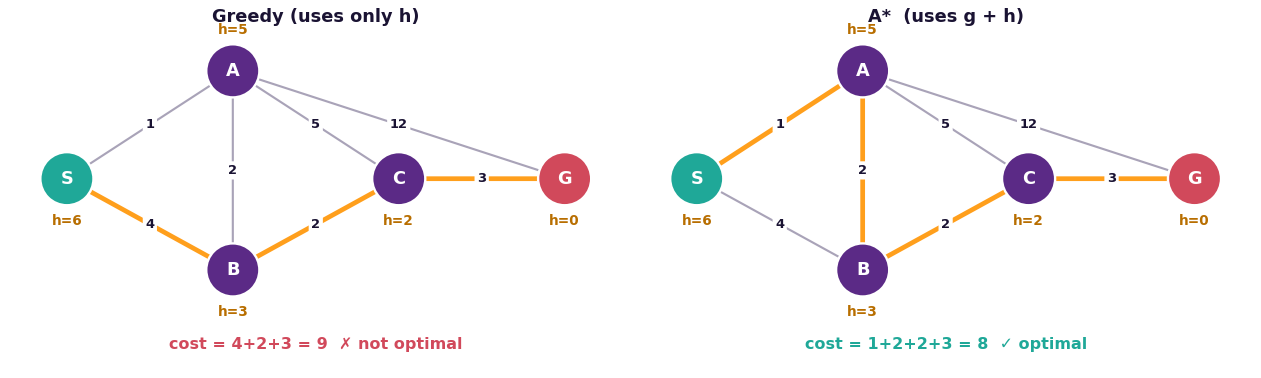

In [ ]:
#@title 📊 Visual explanation: greedy vs A* on the same graph
def fig_greedy_vs_astar():
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
    names = {n: n for n in SG["pos"]}
    for ax, path, title, cost, col in [(axes[0], ["S", "B", "C", "G"], "Greedy (uses only h)", "cost = 4+2+3 = 9  ✗ not optimal", ROSE),
                                        (axes[1], ["S", "A", "B", "C", "G"], "A*  (uses g + h)", "cost = 1+2+2+3 = 8  ✓ optimal", TEAL)]:
        draw_graph(ax, SG["pos"], SG["edges"], weights=SG["w"], colors={"S": TEAL, "G": ROSE}, path=path, r=0.32, fs=15)
        for n, (x, y) in SG["pos"].items():
            ax.text(x, y - 0.55 if y < 2 else y + 0.45, f"h={SG['h'][n]}", ha="center", fontsize=11.5,
                    color="#B86E00", fontweight="bold")
        ax.set_title(title, fontsize=15, fontweight="bold", color=DARK)
        ax.text(3, -1.05, cost, ha="center", fontsize=13.5, fontweight="bold", color=col)
        ax.set_ylim(-1.3, 2.8)
    finish(fig)
    return fig

fig_greedy_vs_astar()
plt.show()

In [ ]:
# ===== The small example graph from the slides =====
graph = {
    "S": {"A": 1, "B": 4},
    "A": {"S": 1, "B": 2, "C": 5, "G": 12},
    "B": {"S": 4, "A": 2, "C": 2},
    "C": {"A": 5, "B": 2, "G": 3},
    "G": {"A": 12, "C": 3},
}
h = {"S": 6, "A": 5, "B": 3, "C": 2, "G": 0}    # heuristic: estimated distance to G
print("Heuristic values:", h)

In [ ]:
# ===== Greedy Best-First Search: f(n) = h(n) =====
import heapq

def greedy(graph, h, start, goal):
    frontier = [(h[start], [start])]
    explored = set()
    while frontier:
        f, path = heapq.heappop(frontier)       # smallest h first
        node = path[-1]
        if node in explored:
            continue
        print(f"expand {node}  (h = {h[node]})")
        if node == goal:
            return path
        explored.add(node)
        for child in graph[node]:
            if child not in explored:
                heapq.heappush(frontier, (h[child], path + [child]))

def cost_of(graph, path):
    return sum(graph[a][b] for a, b in zip(path, path[1:]))

p = greedy(graph, h, "S", "G")
print("Greedy path:", " → ".join(p), "| cost =", cost_of(graph, p))

Greedy rushed to **B** because h(B) = 3 looked small, but the road S→B costs 4. Now A\*:

In [ ]:
# ===== A* Search: f(n) = g(n) + h(n) =====
def astar(graph, h, start, goal, verbose=True):
    frontier = [(h[start], 0, [start])]          # (f, g, path)
    best_g = {start: 0}
    expanded = 0
    while frontier:
        f, g, path = heapq.heappop(frontier)      # smallest f first
        node = path[-1]
        if g > best_g.get(node, float("inf")):
            continue                              # an old, more expensive entry
        expanded += 1
        if verbose:
            print(f"expand {str(node):11s} g = {g:4d}   h = {h[node]:4d}   f = g + h = {f:4d}")
        if node == goal:
            return path, g, expanded
        for child, cost in graph[node].items():
            g2 = g + cost
            if g2 < best_g.get(child, float("inf")):
                best_g[child] = g2
                heapq.heappush(frontier, (g2 + h[child], g2, path + [child]))
    return None, None, expanded

p, c, _ = astar(graph, h, "S", "G")
print("A* path:", " → ".join(p), "| cost =", c)

A\* found the cheaper path (cost 8), because it also counts the distance already travelled.

---
## Part 2: A* on the city map
Our heuristic is the **straight-line distance** to Multan. A road can never be shorter than a straight line, so this heuristic **never overestimates** — it is **admissible**, and A\* is guaranteed to find the best route.

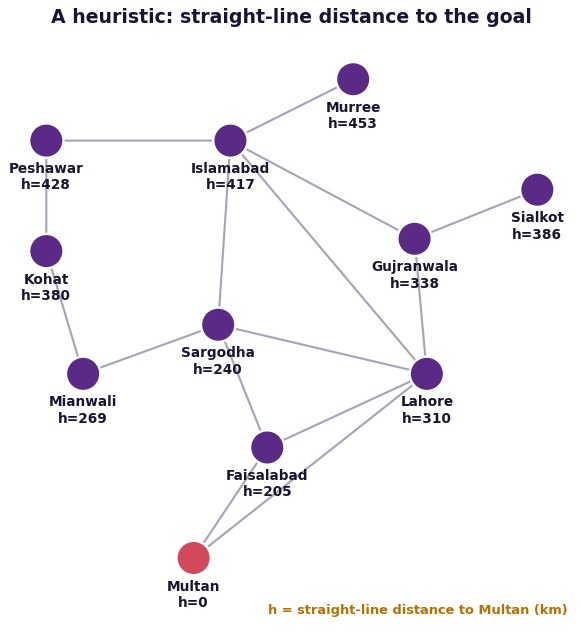

In [ ]:
#@title 📊 Visual explanation: h = straight-line distance to Multan
def fig_heuristic_map():
    roads, _ = _map()
    coords = _layout()
    h = {"Peshawar": 428, "Kohat": 380, "Islamabad": 417, "Murree": 453, "Mianwali": 269, "Sargodha": 240,
         "Gujranwala": 338, "Sialkot": 386, "Lahore": 310, "Faisalabad": 205, "Multan": 0}
    fig, ax = plt.subplots(figsize=(10, 7.6))
    names = {c: f"{c}\nh={h[c]}" for c in coords}
    draw_graph(ax, coords, [(a, b) for a, b, _ in roads], colors={"Multan": ROSE}, r=0.28, fs=11.5,
               label_below=True, names=names)
    ax.set_ylim(-1.9, 7.6)
    ax.text(8.5, -1.7, "h = straight-line distance to Multan (km)", ha="right", fontsize=11, color="#B86E00",
            fontweight="bold")
    finish(fig, "A heuristic: straight-line distance to the goal")
    return fig

fig_heuristic_map()
plt.show()

In [ ]:
# ===== A* on the city map with straight-line distance as the heuristic =====
roads = {
    "Peshawar":   {"Islamabad": 185, "Kohat": 65},
    "Kohat":      {"Peshawar": 65, "Mianwali": 190},
    "Islamabad":  {"Peshawar": 185, "Murree": 60, "Sargodha": 230, "Gujranwala": 225, "Lahore": 375},
    "Murree":     {"Islamabad": 60},
    "Mianwali":   {"Kohat": 190, "Sargodha": 145},
    "Sargodha":   {"Islamabad": 230, "Mianwali": 145, "Faisalabad": 95, "Lahore": 190},
    "Gujranwala": {"Islamabad": 225, "Lahore": 70, "Sialkot": 55},
    "Sialkot":    {"Gujranwala": 55},
    "Lahore":     {"Islamabad": 375, "Gujranwala": 70, "Sargodha": 190, "Faisalabad": 180, "Multan": 340},
    "Faisalabad": {"Sargodha": 95, "Lahore": 180, "Multan": 240},
    "Multan":     {"Faisalabad": 240, "Lahore": 340},
}
# straight-line ("as the crow flies") distance from each city to Multan, in km
h_multan = {"Peshawar": 428, "Kohat": 380, "Islamabad": 417, "Murree": 453, "Mianwali": 269,
            "Sargodha": 240, "Gujranwala": 338, "Sialkot": 386, "Lahore": 310, "Faisalabad": 205, "Multan": 0}

path, cost, n = astar(roads, h_multan, "Peshawar", "Multan")
print("\nA* path:", " → ".join(path), "|", cost, "km |", n, "cities expanded")

In [ ]:
# ===== Is the heuristic helping? Compare with h = 0 (that is just Uniform-Cost Search) =====
zero = {city: 0 for city in roads}
_, cost0, n0 = astar(roads, zero, "Peshawar", "Multan", verbose=False)
_, cost1, n1 = astar(roads, h_multan, "Peshawar", "Multan", verbose=False)
print(f"UCS (h = 0)          : {cost0} km, {n0} cities expanded")
print(f"A*  (straight-line h): {cost1} km, {n1} cities expanded")
print("Same best route, but A* looked at fewer cities because the heuristic points it towards Multan.")

---
## Part 3: 8-puzzle — which heuristic is better?
- **h1** = number of tiles in the wrong place
- **h2** = Manhattan distance = total up/down + left/right steps each tile needs

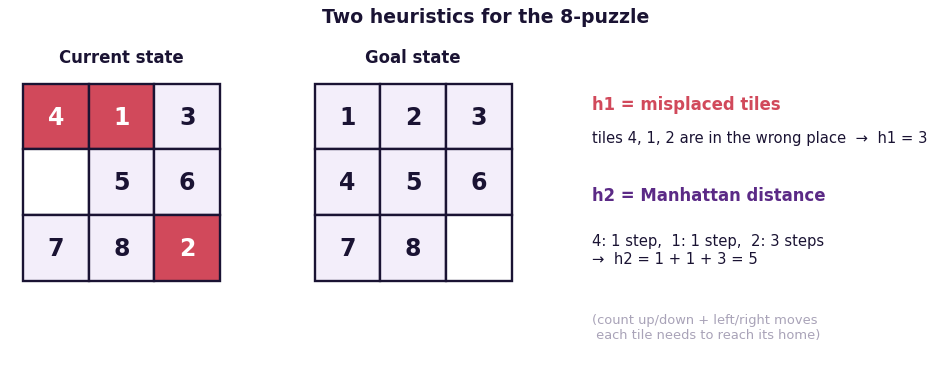

In [ ]:
#@title 📊 Visual explanation: computing h1 and h2
def fig_manhattan():
    fig, ax = plt.subplots(figsize=(12, 4.6))
    start, goal = "413056782", "123456780"
    board(ax, 0.2, 2.0, start, title="Current state", highlight={"4": ROSE, "1": ROSE, "2": ROSE})
    board(ax, 4.2, 2.0, goal, title="Goal state")
    ax.text(8.0, 2.55, "h1 = misplaced tiles", fontsize=14, fontweight="bold", color=ROSE)
    ax.text(8.0, 2.1, "tiles 4, 1, 2 are in the wrong place  →  h1 = 3", fontsize=12.5, color=DARK)
    ax.text(8.0, 1.3, "h2 = Manhattan distance", fontsize=14, fontweight="bold", color=PURPLE)
    ax.text(8.0, 0.85, "4: 1 step,  1: 1 step,  2: 3 steps\n→  h2 = 1 + 1 + 3 = 5", fontsize=12.5, color=DARK, va="top")
    ax.text(8.0, -0.25, "(count up/down + left/right moves\n each tile needs to reach its home)", fontsize=11, color=GREY, va="top")
    ax.set_xlim(0, 12.3); ax.set_ylim(-1.1, 3.4); ax.set_aspect("equal"); ax.axis("off")
    finish(fig, "Two heuristics for the 8-puzzle")
    return fig

fig_manhattan()
plt.show()

In [ ]:
# ===== 8-Puzzle with A*: misplaced tiles (h1) vs Manhattan distance (h2) =====
GOAL = "123456780"

def h1(state):                          # number of tiles in the wrong place
    return sum(1 for i, t in enumerate(state) if t != "0" and t != GOAL[i])

def h2(state):                          # total Manhattan distance of all tiles
    total = 0
    for i, t in enumerate(state):
        if t != "0":
            j = GOAL.index(t)
            total += abs(i // 3 - j // 3) + abs(i % 3 - j % 3)
    return total

def neighbours(state):
    i = state.index("0"); r, c = divmod(i, 3)
    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        nr, nc = r + dr, c + dc
        if 0 <= nr < 3 and 0 <= nc < 3:
            j = nr * 3 + nc
            s = list(state); s[i], s[j] = s[j], s[i]
            yield "".join(s)

def astar_puzzle(start, hfun):
    frontier = [(hfun(start), 0, start)]
    best_g = {start: 0}
    expanded = 0
    while frontier:
        f, g, s = heapq.heappop(frontier)
        if g > best_g[s]:
            continue
        expanded += 1
        if s == GOAL:
            return g, expanded
        for n in neighbours(s):
            if g + 1 < best_g.get(n, float("inf")):
                best_g[n] = g + 1
                heapq.heappush(frontier, (g + 1 + hfun(n), g + 1, n))

start = "413056782"
print("Start state h1 =", h1(start), " h2 =", h2(start))
for name, hf in [("h = 0 (no heuristic)", lambda s: 0), ("h1 misplaced tiles", h1), ("h2 Manhattan", h2)]:
    moves, expanded = astar_puzzle(start, hf)
    print(f"{name:22s}: solution = {moves} moves, states expanded = {expanded}")

All three find the same **13-move** solution, but look at **states expanded**. A better heuristic (h2) means **much less work**.

In [ ]:
# ===== A harder puzzle shows the difference more clearly =====
hard = "867254301"
for name, hf in [("h1 misplaced tiles", h1), ("h2 Manhattan", h2)]:
    moves, expanded = astar_puzzle(hard, hf)
    print(f"{name:20s}: solution = {moves} moves, states expanded = {expanded}")

---
## Part 4: Hill Climbing
Hill climbing is like climbing a hill in thick fog: you can only see the ground next to you, so you **always step uphill**. It is fast and uses almost no memory, but it can get **stuck**.

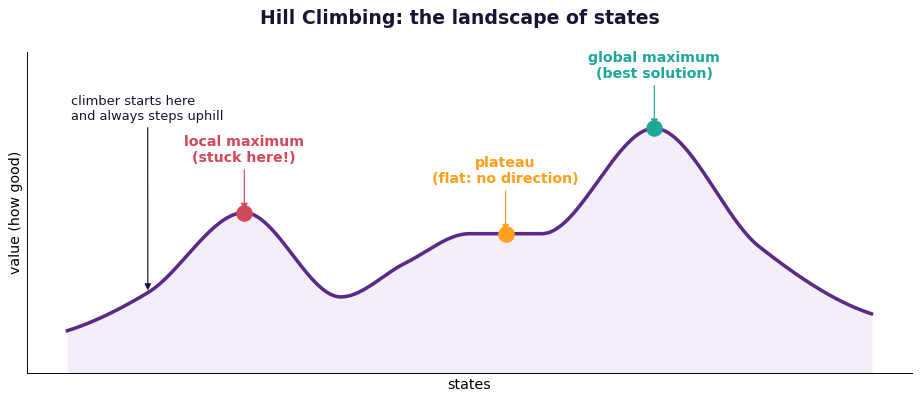

In [ ]:
#@title 📊 Visual explanation: local maximum, plateau and global maximum
def fig_hill_climbing():
    import numpy as np
    from scipy.interpolate import PchipInterpolator
    cx_ = [0, 1.0, 2.2, 3.4, 4.2, 5.0, 5.9, 7.3, 8.6, 10]
    cy_ = [1.0, 1.9, 3.8, 1.8, 2.6, 3.3, 3.3, 5.8, 3.0, 1.4]
    x = np.linspace(0, 10, 600); y = PchipInterpolator(cx_, cy_)(x)
    fig, ax = plt.subplots(figsize=(11, 4.8))
    ax.fill_between(x, 0, y, color=LIGHT); ax.plot(x, y, color=PURPLE, lw=3)
    pts = {"local maximum\n(stuck here!)": (2.2, ROSE), "global maximum\n(best solution)": (7.3, TEAL), "plateau\n(flat: no direction)": (5.45, ORANGE)}
    for t, (px, c) in pts.items():
        py = np.interp(px, x, y)
        ax.plot(px, py, "o", ms=13, color=c, zorder=5)
        ax.annotate(t, xy=(px, py), xytext=(px, py + 1.2), ha="center", fontsize=12, fontweight="bold", color=c,
                    arrowprops=dict(arrowstyle="-|>", color=c))
    cx = 1.0; cy = np.interp(cx, x, y)
    ax.annotate("climber starts here\nand always steps uphill", xy=(cx, cy), xytext=(0.05, 6.0), fontsize=11, color=DARK,
                arrowprops=dict(arrowstyle="-|>", color=DARK))
    ax.set_xlabel("states", fontsize=12); ax.set_ylabel("value (how good)", fontsize=12)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_ylim(0, 7.6); ax.spines[["top", "right"]].set_visible(False)
    finish(fig, "Hill Climbing: the landscape of states")
    return fig

fig_hill_climbing()
plt.show()

In [ ]:
# ===== Hill Climbing on a 1-D landscape =====
import numpy as np, random
import matplotlib.pyplot as plt

def value(x):                                    # the "height" of each state x = 0..100
    return 3 * np.exp(-(x - 22) ** 2 / 90) + 5 * np.exp(-(x - 73) ** 2 / 130)

def hill_climb(x):
    path = [x]
    while True:
        neighbours = [n for n in (x - 1, x + 1) if 0 <= n <= 100]
        best = max(neighbours, key=value)
        if value(best) <= value(x):              # no neighbour is higher: stop
            return x, path
        x = best; path.append(x)

xs = np.arange(0, 101)
plt.figure(figsize=(11, 4))
plt.plot(xs, value(xs), color="#5B2A86", lw=3)
for start, colour in [(5, "#D1495B"), (55, "#1FA898")]:
    top, path = hill_climb(start)
    plt.plot(path, value(np.array(path)), "o-", color=colour, ms=4,
             label=f"start {start} → stops at {top} (value {value(top):.2f})")
plt.legend(); plt.xlabel("state"); plt.ylabel("value"); plt.title("Hill climbing: where you start decides where you stop")
plt.show()

### Fix: random restarts
If you might get stuck, **start again from random places** and keep the best result.

In [ ]:
# ===== Fix: Random-restart hill climbing =====
random.seed(1)
best_x = None
for trial in range(1, 6):
    s = random.randint(0, 100)
    top, _ = hill_climb(s)
    print(f"Restart {trial}: start at {s:3d} → reached {top:3d}  (value {value(top):.2f})")
    if best_x is None or value(top) > value(best_x):
        best_x = top
print("Best found:", best_x, f"(value {value(best_x):.2f})")

---
## Part 5: Game search — Minimax
In a game, **MAX** (you) wants a high score and **MIN** (the opponent) wants a low score. Minimax assumes both play their best.

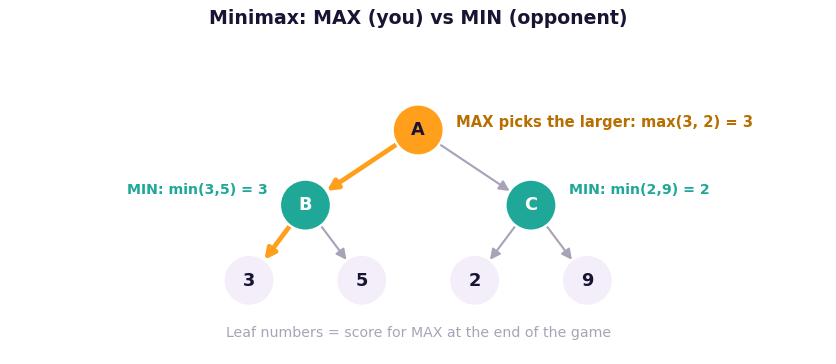

In [ ]:
#@title 📊 Visual explanation: minimax on a tiny game tree
def fig_minimax():
    children = {"A": ["B", "C"], "B": ["3", "5"], "C": ["2", "9"]}
    pos = tree_layout(children, "A", gap=1.5)
    edges = [(p, c) for p, ks in children.items() for c in ks]
    fig, ax = plt.subplots(figsize=(10, 4.8))
    cols = {"A": ORANGE, "B": TEAL, "C": TEAL, "3": LIGHT, "5": LIGHT, "2": LIGHT, "9": LIGHT}
    draw_graph(ax, pos, edges, directed=True, colors=cols, r=0.34, fs=15, path=["A", "B", "3"])
    ax.text(pos["A"][0] + 0.5, 0.05, "MAX picks the larger: max(3, 2) = 3", fontsize=12.5, color="#B86E00", fontweight="bold")
    ax.text(pos["B"][0] - 0.5, -0.85, "MIN: min(3,5) = 3", fontsize=12, color=TEAL, fontweight="bold", ha="right")
    ax.text(pos["C"][0] + 0.5, -0.85, "MIN: min(2,9) = 2", fontsize=12, color=TEAL, fontweight="bold")
    ax.text(pos["A"][0], -2.75, "Leaf numbers = score for MAX at the end of the game", ha="center", fontsize=12, color=GREY)
    ax.set_xlim(pos["3"][0] - 3.2, pos["9"][0] + 3.2); ax.set_ylim(-3.0, 0.6)
    finish(fig, "Minimax: MAX (you) vs MIN (opponent)")
    return fig

fig_minimax()
plt.show()

In [ ]:
# ===== Minimax on the small game tree from the slides =====
game_tree = {"A": ["B", "C"], "B": [3, 5], "C": [2, 9]}

def minimax(node, is_max):
    if isinstance(node, int):          # a leaf: the final score
        return node
    scores = [minimax(child, not is_max) for child in game_tree[node]]
    best = max(scores) if is_max else min(scores)
    print(f"{'MAX' if is_max else 'MIN'} at {node}: children {scores} → chooses {best}")
    return best

print("Value of the game for MAX:", minimax("A", True))

---
## 📝 Lab Tasks
1. Change `h["A"]` to **10** in the small graph and run A\* again. Is the answer still optimal? Why? (*Hint:* is h still admissible?)
2. Use A\* to find the best route from **Sialkot to Multan**. How many cities does it expand compared with UCS (h = 0)?
3. Try the 8-puzzle start `"182043765"` with h1 and h2. Record moves and states expanded.
4. In hill climbing, try 20 random restarts. How often do you reach the global maximum (x = 73)?
5. Change the leaves of the minimax tree to `[3, 12]` and `[8, 2]`. What does MAX choose now?